In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

In [43]:
# df_5m = pd.read_csv("C:\Campbellsci\PC400\CR1000_2_Light.dat", header = 1, skiprows=[2, 3],
#                     dtype = {'TIMESTAMP': str, 'Shadow_Min': np.float64, 'Shadow_TMn': str, 'Shadow_Avg':np.float64, 
#                              'Clear_Avg':np.float64,'Bar_Avg':np.float64, 'Shadowfiveminavg_Avg':np.float64,
#                                'Stot':np.float64, 'Sbeam':np.float64, 'Sdiff':np.float64}, na_values = ['NAN'])

# df_hr = pd.read_csv("C:\Campbellsci\PC400\CR1000_2_Light2.dat", header = 1, skiprows=[2, 3], 
#                     dtype = {'TIMESTAMP': str, 'Shadow_Avg':np.float64, 
#                              'Clear_Avg':np.float64,'Bar_Avg':np.float64, 'Shadowfiveminavg_Avg':np.float64,
#                                'Stot':np.float64, 'Sbeam':np.float64, 'Sdiff':np.float64}, na_values = ['NAN'])

# dt_ts = pd.to_datetime(df_5m['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S')
# df_5m.set_index(dt_ts, inplace = True)

# dt_ts = pd.to_datetime(df_hr['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S')
# df_hr.set_index(dt_ts, inplace = True)


In [ ]:
startdate = dt.datetime(2025, 1, 1)
enddate = dt.datetime(2025, 10, 1)
r = pd.date_range(start=startdate, end=enddate, freq = '30min')
hh_index = np.arange(0, 24, 0.5)

#Shadowband data - 5 min freq
sb = pd.read_csv(r"C:\Users\emily\Documents\Grad_School\Research\Agrivoltaics\Data\Shadowband\Light_20250827.dat", header = 1, skiprows=[2, 3], 
                    dtype = {'TIMESTAMP': str, 'Shadow_Avg':np.float64, 
                             'Clear_Avg':np.float64,'Bar_Avg':np.float64, 'Shadowfiveminavg_Avg':np.float64,
                               'Stot':np.float64, 'Sbeam':np.float64, 'Sdiff':np.float64}, na_values = ['NAN'])

#shadowband is in UTC, but for some reason the Stot, Sbeam, and Sdiff columns are averages from the previous hour so they are actually 7 hours off -
#Eventually, do look at code and do calcs with Clear_Avg and Shadow_min #fixthis
dt_ts = pd.to_datetime(sb['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 7)
sb.set_index(dt_ts, inplace = True)

sb_hh = sb.resample('30min').mean().reindex(r).rename_axis('TIMESTAMP') #Resampe to 30min
sb_hr = sb.select_dtypes('number').resample('1h').mean()#.reindex(r).rename_axis('TIMESTAMP') #Resampe to 30min

#KSC biomet data
KSC_bm = pd.read_csv(r'C:\Users\emily\Documents\Grad_School\Research\Agrivoltaics\Data\KSC_full_biomet.csv', header = [0], skiprows = [1])

dt_ts = pd.to_datetime(KSC_bm['TIMESTAMP_1'], format = '%Y-%m-%d %H:%M:%S') -  dt.timedelta(hours = 6)
KSC_bm.set_index(dt_ts, inplace = True)

KSC_bm_hh = KSC_bm.select_dtypes('number').resample('30min').mean().rename_axis('TIMESTAMP') #Resampe to 30min

#KSA biomet data
KSA_bm = pd.read_csv(r'C:\Users\emily\Documents\Grad_School\Research\Agrivoltaics\Data\KSA_full_biomet.csv', header = [0], skiprows = [1])

dt_ts = pd.to_datetime(KSA_bm['TIMESTAMP_1'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6)
KSA_bm.set_index(dt_ts, inplace = True)

KSA_bm_hh = KSA_bm.select_dtypes('number').resample('30min').mean().rename_axis('TIMESTAMP') #Resampe to 30min


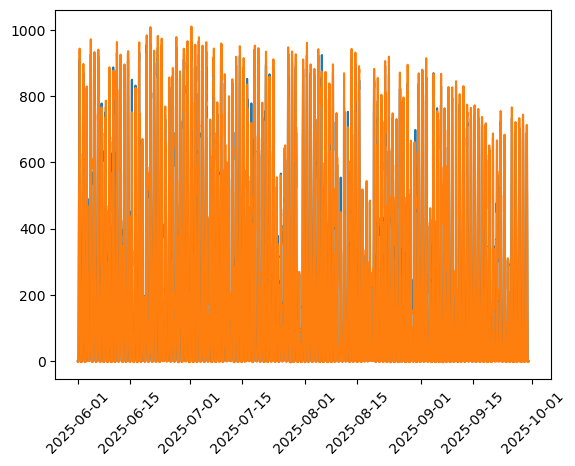

In [45]:
cf = 1/2.02 #micromol/m^2/s PAR (400-700 nm) to W/m^2 (full SW spectrum) (Source: https://doi.org/10.31062/agrom.v27i2.26527)
#0.327/0.473 #Conversion factor ppfd to W/m^2
startdate = dt.datetime(2025, 6, 1)
enddate = dt.datetime(2025, 9, 30)
# plt.plot((sb_hr['Stot']*cf)[startdate:enddate])
plt.plot(KSC_bm_hh['SWin'][startdate:enddate])
plt.plot(KSA_bm_hh['SWin'][startdate:enddate])
plt.xticks(rotation = 45);

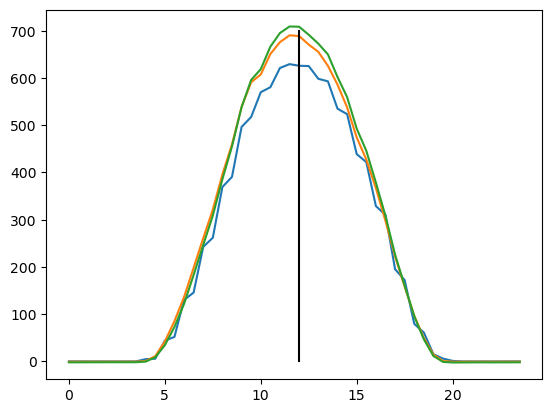

In [46]:

startdate = dt.datetime(2025, 6, 1)
enddate = dt.datetime(2025, 8, 26)
sb_day = sb_hh[startdate:enddate].groupby(sb_hh[startdate:enddate].index.time).mean()
KSC_bm_day = KSC_bm_hh[startdate:enddate].groupby(KSC_bm_hh[startdate:enddate].index.time).mean()
KSA_bm_day = KSA_bm_hh[startdate:enddate].groupby(KSA_bm_hh[startdate:enddate].index.time).mean()

plt.plot(hh_index, sb_day['Stot'].values*cf)
plt.plot(hh_index, KSC_bm_day['SWin'].values)
plt.plot(hh_index, KSA_bm_day['SWin'].values)
plt.plot([12, 12], [0, 700], c = 'k')

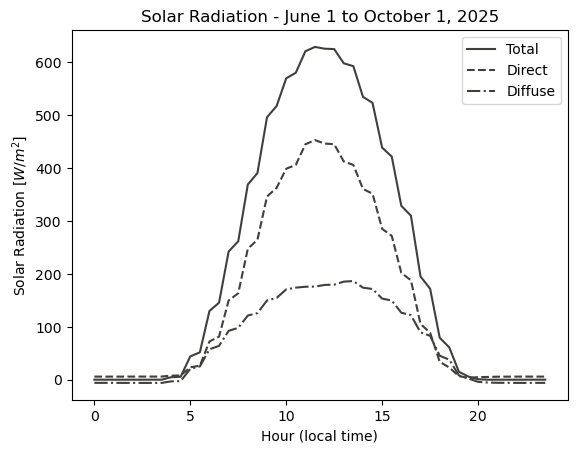

In [47]:
plt.plot(hh_index, sb_day['Stot'].values*cf, c= "#403F3C", label = 'Total')
plt.plot(hh_index, sb_day['Sbeam'].values*cf, c= "#403F3C", linestyle = '--', label = 'Direct')
plt.plot(hh_index, sb_day['Sdiff'].values*cf, c = "#403F3C", linestyle = '-.', label = 'Diffuse')
# plt.plot(hh_index, sb_day['Shadow_Min'])

plt.xlabel('Hour (local time)');
plt.ylabel('Solar Radiation [$W/m^2$]');
plt.title('Solar Radiation - June 1 to October 1, 2025')
plt.legend()
plt.savefig(r'C:\Users\emily\Documents\Grad_School\Research\Agrivoltaics\Figures\Shadowband_dir and_diff_mean_diel.png')

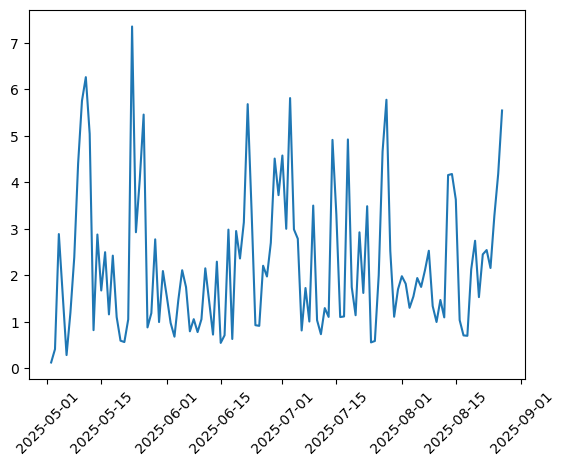

In [63]:
dir_diff_rat = sb['Sbeam']/sb['Sdiff']
dir_diff_rat = dir_diff_rat.where((sb['Sbeam']>=0)&(sb['Sdiff']>=0))
dir_diff_rat_1day_avg = dir_diff_rat.resample('1D').mean().rename_axis('TIMESTAMP') #Resampe to 1 day
plt.plot(dir_diff_rat_1day_avg)
plt.xticks(rotation = 45);

TIMESTAMP
2025-05-02 08:20:00    True
2025-05-02 08:25:00    True
2025-05-02 08:30:00    True
2025-05-02 08:35:00    True
2025-05-02 08:40:00    True
                       ... 
2025-08-27 10:30:00    True
2025-08-27 10:35:00    True
2025-08-27 10:40:00    True
2025-08-27 05:45:00    True
2025-08-27 10:50:00    True
Length: 33727, dtype: bool

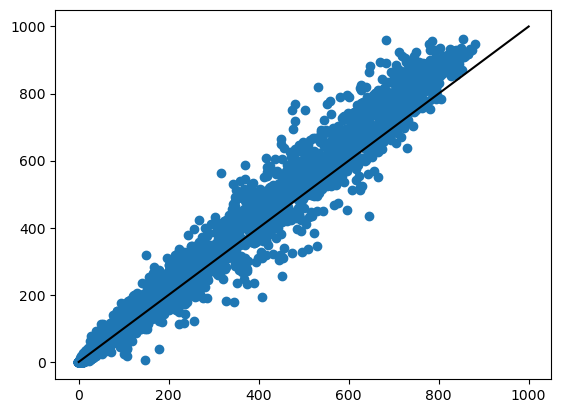

In [48]:

x = (sb_hh['Stot']*cf)[startdate:enddate]
y = KSC_bm_hh['SWin'][startdate:enddate]
plt.scatter(x, y)
plt.plot([0, 1000], [0, 1000], c = 'k')

In [49]:
startdate = dt.datetime(2025, 5, 10)
enddate = dt.datetime(2025, 5, 31)
plt.plot(df_5m.Stot[startdate:enddate], label = 'Total')
plt.plot(df_5m.Sbeam[startdate:enddate], label = 'Beam')
plt.plot(df_5m.Sdiff[startdate:enddate], label = 'Diffuse')
# plt.plot(df_5m.Bar_Avg)
plt.xticks(rotation = 45);
plt.legend()
plt.ylabel('Radiation [units?]')


NameError: name 'df_5m' is not defined

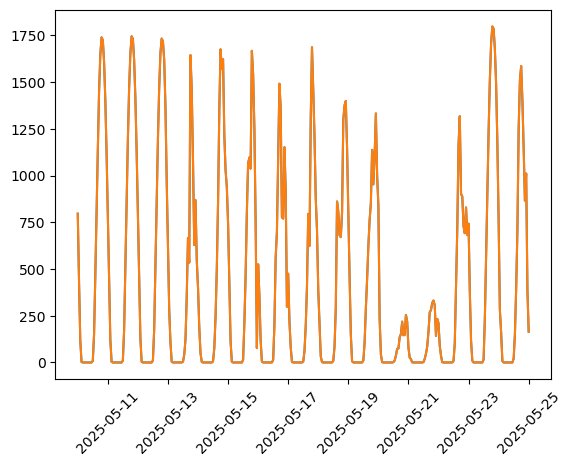

In [ ]:

# plt.plot(df_hr.Sbeam[startdate:enddate])
# plt.plot(df_hr.Sdiff[startdate:enddate])
plt.plot(df_hr.Sbeam[startdate:enddate] + df_hr.Sdiff[startdate:enddate])
plt.plot(df_hr.Stot[startdate:enddate])
plt.xticks(rotation = 45);